<a href="https://colab.research.google.com/github/alinematosdev/neural-network-experiment/blob/main/neural_network_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

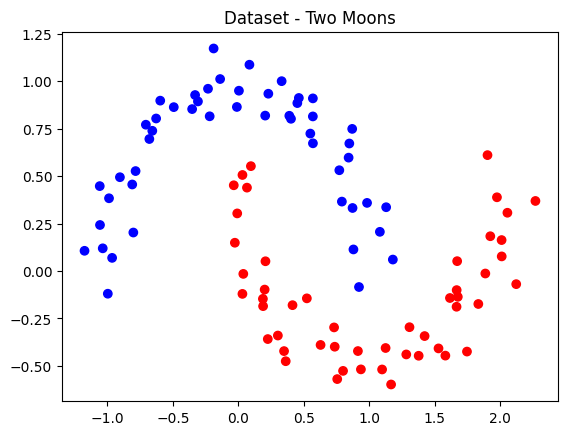

In [1]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

X, Y = datasets.make_moons(100, noise=0.1, random_state=42)

color = ['blue' if k == 0 else 'red' for k in Y]

plt.scatter(X[:, 0], X[:, 1], c=color)
plt.title('Dataset - Two Moons')
plt.show()

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)

## Original Model — Sigmoid + MSE

The original neural network contains two input variables, two neurons in the hidden layer using the Sigmoid activation function, and one output neuron using Sigmoid.

The Mean Squared Error (MSE) is used as the loss function.

In [3]:
def run_neural_net_original(x, w0, b0, b1, w1):
    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = sigmoid(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = sigmoid(v1)

    s20 = y0 * w1[0]
    s21 = y1 * w1[1]
    s22 = s20 + s21
    v2 = s22 + b1[0]
    y2 = sigmoid(v2)
    return 1 if y2 > 0.5 else 0


def neural_net_original(x, d, w0, b0, b1, w1):
    # forward

    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = sigmoid(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = sigmoid(v1)

    s20 = y0 * w1[0]
    s21 = y1 * w1[1]
    s22 = s20 + s21
    v2 = s22 + b1[0]
    y2 = sigmoid(v2)
    e = y2 - d
    L = 1/2 * (e ** 2)


    # backward
    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    grad_L = 1
    grad_e = grad_L * e

    grad_y2 = grad_e
    grad_v2 = grad_y2 * y2 * (1 - y2)
    grad_b1[0] = grad_v2
    grad_s22 = grad_v2
    grad_s21 = grad_s22
    grad_s20 = grad_s22
    grad_w1[1] = grad_s21 * y1
    grad_y1 = grad_s21 * w1[1]

    grad_w1[0] = grad_s20 * y0
    grad_y0 = grad_v2 * w1[0]

    grad_v0 = grad_y0 * y0 * (1 - y0)
    grad_v1 = grad_y1 * y1 * (1 - y1)

    grad_b0[0] = grad_v0
    grad_b0[1] = grad_v1
    grad_s12 = grad_v1
    grad_s02 = grad_v0

    grad_s00 = grad_s02
    grad_s01 = grad_s02
    grad_s10 = grad_s12
    grad_s11 = grad_s12
    grad_w0[0, 0] = grad_s00 * x[0]
    grad_w0[0, 1] = grad_s01 * x[1]
    grad_w0[1, 0] = grad_s10 * x[0]
    grad_w0[1, 1] = grad_s11 * x[1]
    return grad_w0, grad_b0, grad_w1, grad_b1, L

In [4]:
np.random.seed(42)

# inicialização aleatória
w0 = np.random.rand(2, 2)
w1 = np.random.rand(2)
b0 = np.random.rand(2)
b1 = np.random.rand(1)

# taxa de aprendizado
taxa = 0.1

acc = 0
for i in range(100):
    out = run_neural_net_original(X[i], w0, b0, b1, w1)
    if out == Y[i]:
        acc += 1

print(acc, "acurácia antes do treinamento")

loss_original = []

# gradiente descendente
for i in range(10000):
    loss = 0

    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    for k in range(100):
        g_w0, g_b0, g_w1, g_b1, L = neural_net_original(
            X[k], Y[k], w0, b0, b1, w1
        )

        grad_w0 += g_w0
        grad_w1 += g_w1
        grad_b0 += g_b0
        grad_b1 += g_b1
        loss += L

    w0 -= taxa * grad_w0
    w1 -= taxa * grad_w1
    b0 -= taxa * grad_b0
    b1 -= taxa * grad_b1

    loss_original.append(loss)

    if i % 1000 == 0:
        print(i, loss)

# acurácia após o treinamento
acc_original = 0
for i in range(100):
    out = run_neural_net_original(X[i], w0, b0, b1, w1)
    if out == Y[i]:
        acc_original += 1

print('acc', acc_original)

50 acurácia antes do treinamento
0 14.405538406786004
1000 3.9108715007299564
2000 3.799691444048184
3000 3.7767635664924306
4000 3.766634531139349
5000 3.7605680082264366
6000 3.756369264486822
7000 3.7532163144922563
8000 3.750721211596938
9000 3.754607114751502
acc 89


## Experiment 1 — Tanh + MSE

In the first modification, the Sigmoid activation function in the hidden layer is replaced by Tanh.

The output layer continues to use Sigmoid and the loss function remains MSE.

Because backpropagation is implemented manually, the derivative of the hidden activation function is also changed from:

`y * (1 - y)`

to:

`1 - y²`

In [5]:
def run_neural_net_tanh(x, w0, b0, b1, w1):
    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = tanh(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = tanh(v1)

    s20 = y0 * w1[0]
    s21 = y1 * w1[1]
    s22 = s20 + s21
    v2 = s22 + b1[0]
    y2 = sigmoid(v2)
    return 1 if y2 > 0.5 else 0


def neural_net_tanh(x, d, w0, b0, b1, w1):
    # forward

    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = tanh(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = tanh(v1)

    s20 = y0 * w1[0]
    s21 = y1 * w1[1]
    s22 = s20 + s21
    v2 = s22 + b1[0]
    y2 = sigmoid(v2)
    e = y2 - d
    L = 1/2 * (e ** 2)


    # backward
    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    grad_L = 1
    grad_e = grad_L * e

    grad_y2 = grad_e
    grad_v2 = grad_y2 * y2 * (1 - y2)
    grad_b1[0] = grad_v2
    grad_s22 = grad_v2
    grad_s21 = grad_s22
    grad_s20 = grad_s22
    grad_w1[1] = grad_s21 * y1
    grad_y1 = grad_s21 * w1[1]

    grad_w1[0] = grad_s20 * y0
    grad_y0 = grad_v2 * w1[0]

    # MODIFICAÇÃO: derivada da tanh
    grad_v0 = grad_y0 * (1 - y0 ** 2)
    grad_v1 = grad_y1 * (1 - y1 ** 2)

    grad_b0[0] = grad_v0
    grad_b0[1] = grad_v1
    grad_s12 = grad_v1
    grad_s02 = grad_v0

    grad_s00 = grad_s02
    grad_s01 = grad_s02
    grad_s10 = grad_s12
    grad_s11 = grad_s12
    grad_w0[0, 0] = grad_s00 * x[0]
    grad_w0[0, 1] = grad_s01 * x[1]
    grad_w0[1, 0] = grad_s10 * x[0]
    grad_w0[1, 1] = grad_s11 * x[1]
    return grad_w0, grad_b0, grad_w1, grad_b1, L

In [6]:
np.random.seed(42)

# inicialização aleatória
w0 = np.random.rand(2, 2)
w1 = np.random.rand(2)
b0 = np.random.rand(2)
b1 = np.random.rand(1)

# taxa de aprendizado
taxa = 0.1

acc = 0
for i in range(100):
    out = run_neural_net_tanh(X[i], w0, b0, b1, w1)
    if out == Y[i]:
        acc += 1

print(acc, "acurácia antes do treinamento")

loss_tanh = []

# gradiente descendente
for i in range(10000):
    loss = 0

    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    for k in range(100):
        g_w0, g_b0, g_w1, g_b1, L = neural_net_tanh(
            X[k], Y[k], w0, b0, b1, w1
        )

        grad_w0 += g_w0
        grad_w1 += g_w1
        grad_b0 += g_b0
        grad_b1 += g_b1
        loss += L

    w0 -= taxa * grad_w0
    w1 -= taxa * grad_w1
    b0 -= taxa * grad_b0
    b1 -= taxa * grad_b1

    loss_tanh.append(loss)

    if i % 1000 == 0:
        print(i, loss)

# acurácia após o treinamento
acc_tanh = 0
for i in range(100):
    out = run_neural_net_tanh(X[i], w0, b0, b1, w1)
    if out == Y[i]:
        acc_tanh += 1

print('acc', acc_tanh)

50 acurácia antes do treinamento
0 14.378392492995884
1000 3.932044217289273
2000 3.9278588318196204
3000 3.929089985198527
4000 3.93008842211307
5000 3.9307316473480585
6000 3.9311192753292046
7000 3.931331135410296
8000 3.931418490197703
9000 3.9314124027709942
acc 85


## Experiment 2 — Tanh + Binary Cross-Entropy

In the second modification, the Tanh activation function is maintained in the hidden layer, while the Mean Squared Error loss is replaced by Binary Cross-Entropy (BCE).

Since the output layer uses Sigmoid, the combination of Sigmoid and Binary Cross-Entropy simplifies the output gradient to:

`y - d`

In [7]:
def run_neural_net_bce(x, w0, b0, b1, w1):
    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = tanh(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = tanh(v1)

    s20 = y0 * w1[0]
    s21 = y1 * w1[1]
    s22 = s20 + s21
    v2 = s22 + b1[0]
    y2 = sigmoid(v2)
    return 1 if y2 > 0.5 else 0


def neural_net_bce(x, d, w0, b0, b1, w1):
    # forward

    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = tanh(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = tanh(v1)

    s20 = y0 * w1[0]
    s21 = y1 * w1[1]
    s22 = s20 + s21
    v2 = s22 + b1[0]
    y2 = sigmoid(v2)

    # MODIFICAÇÃO: MSE -> Binary Cross-Entropy
    epsilon = 1e-15
    y2_safe = np.clip(y2, epsilon, 1 - epsilon)
    L = -(d * np.log(y2_safe) + (1 - d) * np.log(1 - y2_safe))


    # backward
    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    # MODIFICAÇÃO: derivada da combinação Binary Cross-Entropy + Sigmoid
    grad_v2 = y2 - d

    grad_b1[0] = grad_v2
    grad_s22 = grad_v2
    grad_s21 = grad_s22
    grad_s20 = grad_s22
    grad_w1[1] = grad_s21 * y1
    grad_y1 = grad_s21 * w1[1]

    grad_w1[0] = grad_s20 * y0
    grad_y0 = grad_v2 * w1[0]

    # MODIFICAÇÃO: derivada da tanh
    grad_v0 = grad_y0 * (1 - y0 ** 2)
    grad_v1 = grad_y1 * (1 - y1 ** 2)

    grad_b0[0] = grad_v0
    grad_b0[1] = grad_v1
    grad_s12 = grad_v1
    grad_s02 = grad_v0

    grad_s00 = grad_s02
    grad_s01 = grad_s02
    grad_s10 = grad_s12
    grad_s11 = grad_s12
    grad_w0[0, 0] = grad_s00 * x[0]
    grad_w0[0, 1] = grad_s01 * x[1]
    grad_w0[1, 0] = grad_s10 * x[0]
    grad_w0[1, 1] = grad_s11 * x[1]
    return grad_w0, grad_b0, grad_w1, grad_b1, L

In [8]:
np.random.seed(42)

# inicialização aleatória
w0 = np.random.rand(2, 2)
w1 = np.random.rand(2)
b0 = np.random.rand(2)
b1 = np.random.rand(1)

# taxa de aprendizado
taxa = 0.1

acc = 0
for i in range(100):
    out = run_neural_net_bce(X[i], w0, b0, b1, w1)
    if out == Y[i]:
        acc += 1

print(acc, "acurácia antes do treinamento")

loss_bce = []

# gradiente descendente
for i in range(10000):
    loss = 0

    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    for k in range(100):
        g_w0, g_b0, g_w1, g_b1, L = neural_net_bce(
            X[k], Y[k], w0, b0, b1, w1
        )

        grad_w0 += g_w0
        grad_w1 += g_w1
        grad_b0 += g_b0
        grad_b1 += g_b1
        loss += L

    w0 -= taxa * grad_w0
    w1 -= taxa * grad_w1
    b0 -= taxa * grad_b0
    b1 -= taxa * grad_b1

    loss_bce.append(loss)

    if i % 1000 == 0:
        print(i, loss)

# acurácia após o treinamento
acc_bce = 0
for i in range(100):
    out = run_neural_net_bce(X[i], w0, b0, b1, w1)
    if out == Y[i]:
        acc_bce += 1

print('acc', acc_bce)

50 acurácia antes do treinamento
0 77.49280183373293
1000 37.70061546342547
2000 37.695211495411456
3000 28.117745072034104
4000 28.08309251675039
5000 28.05395895155978
6000 28.03370056706209
7000 28.01684072672764
8000 27.997773668368772
9000 27.968074288335796
acc 90


Original - Sigmoid + MSE: 89 %
Tanh + MSE: 85 %
Tanh + BCE: 90 %


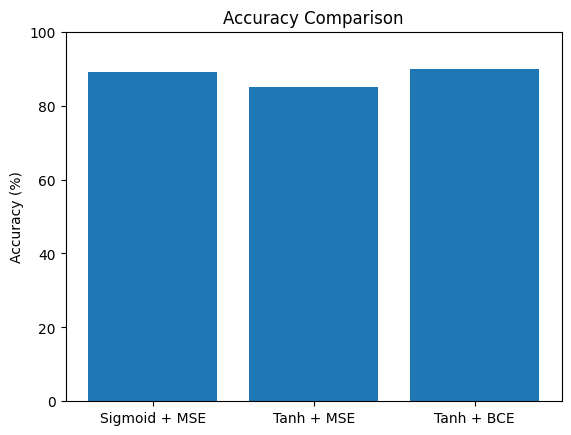

In [9]:
print("Original - Sigmoid + MSE:", acc_original, "%")
print("Tanh + MSE:", acc_tanh, "%")
print("Tanh + BCE:", acc_bce, "%")

models = [
    'Sigmoid + MSE',
    'Tanh + MSE',
    'Tanh + BCE'
]

accuracies = [
    acc_original,
    acc_tanh,
    acc_bce
]

plt.bar(models, accuracies)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison')
plt.ylim(0, 100)
plt.show()

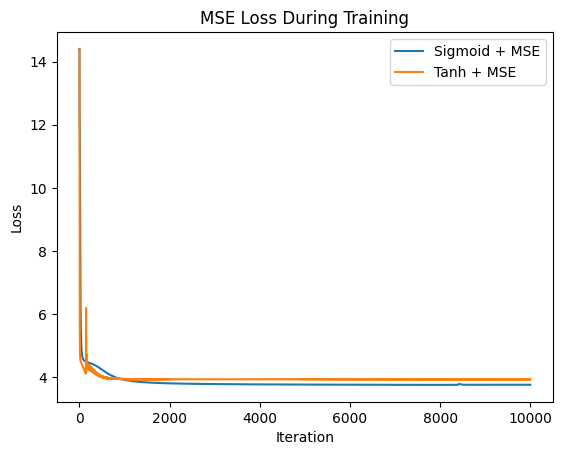

In [10]:
plt.plot(loss_original, label='Sigmoid + MSE')
plt.plot(loss_tanh, label='Tanh + MSE')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MSE Loss During Training')
plt.legend()
plt.show()

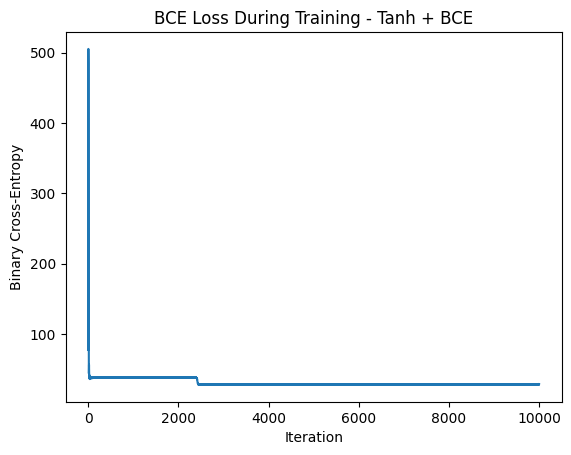

In [11]:
plt.plot(loss_bce)

plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy')
plt.title('BCE Loss During Training - Tanh + BCE')
plt.show()

In [12]:
results = [
    ['Original', 'Sigmoid', 'MSE', f'{acc_original}%'],
    ['Experiment 1', 'Tanh', 'MSE', f'{acc_tanh}%'],
    ['Experiment 2', 'Tanh', 'Binary Cross-Entropy', f'{acc_bce}%']
]

print(f'{"Model":<15} {"Activation":<15} {"Loss":<25} {"Accuracy"}')
print('-' * 70)

for result in results:
    print(f'{result[0]:<15} {result[1]:<15} {result[2]:<25} {result[3]}')

Model           Activation      Loss                      Accuracy
----------------------------------------------------------------------
Original        Sigmoid         MSE                       89%
Experiment 1    Tanh            MSE                       85%
Experiment 2    Tanh            Binary Cross-Entropy      90%
